In [ ]:
from google.colab import files
load = files.upload()
print(load)

Output hidden; open in https://colab.research.google.com to view.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

%matplotlib inline
sns.set_style('whitegrid')

In [19]:
df = pd.read_csv('/content/fake_job_postings.csv')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df.shape

(17880, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [20]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


In [21]:
missing_pct = (missing / len(df) * 100).round(2)
missing_pct

,0
salary_range,83.96
department,64.58
required_education,45.33
benefits,40.34
required_experience,39.43
function,36.10
industry,27.42
employment_type,19.41
company_profile,18.50
requirements,15.08


In [22]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


In [23]:
df['fraudulent'].value_counts(normalize=True) * 100

,proportion
fraudulent,
0,95.1566
1,4.8434


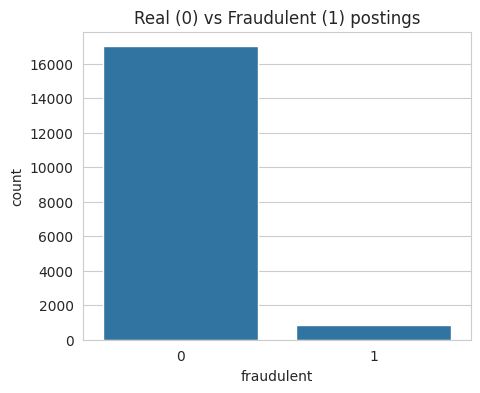

In [24]:
plt.figure(figsize=(5,4))
sns.countplot(x='fraudulent', data=df)
plt.title('Real (0) vs Fraudulent (1) postings')
plt.xlabel('fraudulent')
plt.show()

In [25]:
df.groupby('fraudulent')['has_company_logo'].mean()

,has_company_logo
fraudulent,
0,0.819149
1,0.326790


In [26]:
df.groupby('fraudulent')['telecommuting'].mean()

,telecommuting
fraudulent,
0,0.041319
1,0.073903


In [27]:
ct = pd.crosstab(df['employment_type'], df['fraudulent'], normalize='index') * 100
ct

fraudulent,0,1
employment_type,,
Contract,97.112861,2.887139
Full-time,95.783133,4.216867
Other,93.392070,6.607930
Part-time,90.715182,9.284818
Temporary,99.170124,0.829876


In [28]:
df = df.drop(columns=['job_id', 'salary_range'])
df.shape

(17880, 16)

In [29]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')

cat_cols = ['department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'location']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

df.isnull().sum().sum()

np.int64(0)

In [30]:
df['full_text'] = (df['title'] + ' ' + df['company_profile'] + ' ' +
                    df['description'] + ' ' + df['requirements'] + ' ' + df['benefits'])
df['full_text'].iloc[0][:300]

"Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and "

In [31]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r'<.*?>', ' ', txt)          # strip any leftover html tags
    txt = re.sub(r'http\S+|www\S+', ' ', txt)  # urls
    txt = re.sub(r'[^a-z\s]', ' ', txt)         # numbers/punctuation
    txt = re.sub(r'\s+', ' ', txt).strip()
    tokens = [w for w in txt.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

In [32]:
df['clean_text'] = df['full_text'].apply(clean_text)
df[['full_text', 'clean_text']].sample(3, random_state=1)

,full_text,clean_text
5736,Jr. Business Analyst & Quality Analyst (entry...,business analyst quality analyst entry level d...
7106,English Teacher Abroad We help teachers get s...,english teacher abroad help teachers get safe ...
11978,SQL Server Database Developer Job opportunity ...,sql server database developer job opportunity ...


In [33]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((14304,), (3576,))

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_train_tfidf.shape

(14304, 5000)

### MODEL - 1 LR

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

print('accuracy:', accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

accuracy: 0.9737136465324385
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.46      0.63       173

    accuracy                           0.97      3576
   macro avg       0.99      0.73      0.81      3576
weighted avg       0.97      0.97      0.97      3576



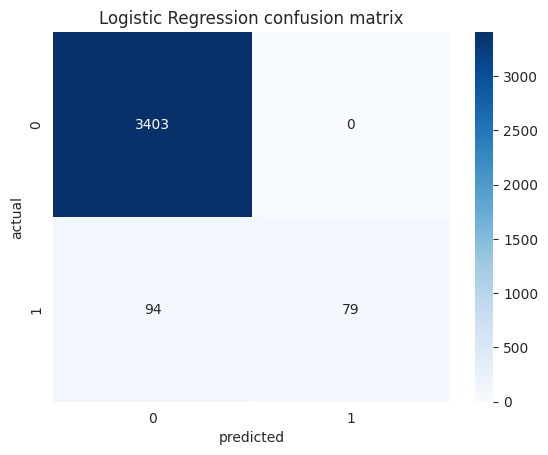

In [37]:
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Logistic Regression confusion matrix')
plt.show()

### MODEL - 2 NB

In [38]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

print('accuracy:', accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

accuracy: 0.9700782997762863
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.90      0.43      0.58       173

    accuracy                           0.97      3576
   macro avg       0.94      0.71      0.78      3576
weighted avg       0.97      0.97      0.96      3576



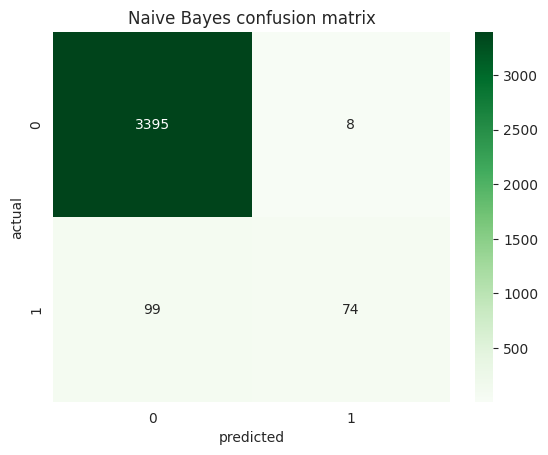

In [39]:
cm_nb = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Naive Bayes confusion matrix')
plt.show()

### MODEL - 3 RANDOM FOREST

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)

print('accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


accuracy: 0.9793064876957495
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.57      0.73       173

    accuracy                           0.98      3576
   macro avg       0.99      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576



### COMPARIING ALL THREE

In [42]:
results = pd.DataFrame({
    'model': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'accuracy': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, nb_pred), accuracy_score(y_test, rf_pred)],
    'precision_fraud': [precision_score(y_test, lr_pred), precision_score(y_test, nb_pred), precision_score(y_test, rf_pred)],
    'recall_fraud': [recall_score(y_test, lr_pred), recall_score(y_test, nb_pred), recall_score(y_test, rf_pred)],
    'f1_fraud': [f1_score(y_test, lr_pred), f1_score(y_test, nb_pred), f1_score(y_test, rf_pred)],
})
results

,model,accuracy,precision_fraud,recall_fraud,f1_fraud
0,Logistic Regression,0.973714,1.000000,0.456647,0.626984
1,Naive Bayes,0.970078,0.902439,0.427746,0.580392
2,Random Forest,0.979306,1.000000,0.572254,0.727941


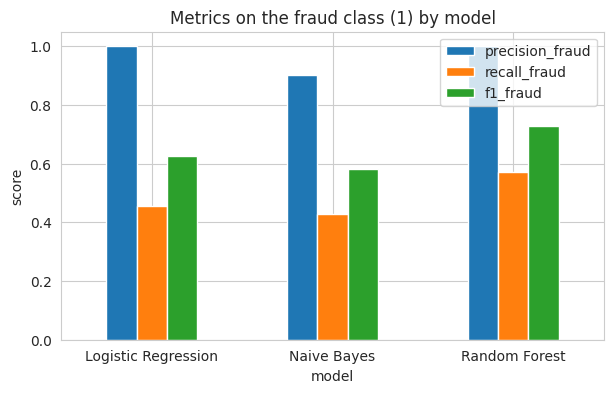

In [43]:
results.set_index('model')[['precision_fraud','recall_fraud','f1_fraud']].plot(kind='bar', figsize=(7,4))
plt.title('Metrics on the fraud class (1) by model')
plt.ylabel('score')
plt.xticks(rotation=0)
plt.show()

### Random Forest comes out ahead on f1 and recall for the fraud class, with precision still at 100%. Logistic regression is close behind and is way faster to train, Naive Bayes is the weakest of the three here. Given the goal is actually catching fraud postings (not just overall accuracy), recall on class 1 matters a lot, so RF looks like the better pick so far - though it's worth checking if that recall improves with some tuning rather than just picking based on default settings.